In [1]:
import numpy as np
import pandas as pd
from pandas import Series, DataFrame

In [2]:
df = pd.read_csv(
    '../../../data/nyc-parking-violations-2020.csv',
    engine = 'pyarrow', # here, using pyarrow makes reading the DataFrame about ~5x faster, this was suggested by Claude
    dtype_backend = 'pyarrow', 
    usecols = ['Plate ID', 'Registration State', 'Vehicle Make', 'Vehicle Color', 'Street Name']
)

In [3]:
df

,Plate ID,Registration State,Vehicle Make,Vehicle Color,Street Name
0,J58JKX,NJ,HONDA,BK,43 ST
1,KRE6058,PA,ME/BE,BLK,UNION ST
2,444326R,NJ,LEXUS,BLACK,CLERMONT AVENUE
3,F728330,OH,CHEVR,<NA>,DIVISION AVE
4,FMY9090,NY,JEEP,GREY,GRAND ST
...,...,...,...,...,...
12495729,62161MM,NY,FORD,BR,3RD AVE
12495730,GYE7330,NY,HONDA,BLK,PELHAM PARK DR
12495731,HNY4802,NY,FORD,GY,LYDIG AVE
12495732,T687081C,NY,TOYOT,BLK,E 68 STREET


In [4]:
len(df['Vehicle Color'].value_counts())

1896

In [5]:
df['Vehicle Color'].value_counts().head(30).index.to_list()

['WH',
 'GY',
 'BK',
 'WHITE',
 'BL',
 'RD',
 'BLACK',
 'GREY',
 'BROWN',
 'SILVE',
 'GR',
 'BLUE',
 'RED',
 'TN',
 'BR',
 'YW',
 'BLK',
 'OTHER',
 'GREEN',
 'GL',
 'GRY',
 'MR',
 'GRAY',
 'WHT',
 'YELLO',
 'WHI',
 'OR',
 'BK.',
 'WT',
 'WT.']

In [6]:
color_map = {
    # WHITE
    'WH':    'WHITE',
    'WHT':   'WHITE',
    'WHI':   'WHITE',
    'WHITE': 'WHITE',
    'WT':    'WHITE',
    'WT.':   'WHITE',

    # BLACK
    'BK':    'BLACK',
    'BK.':   'BLACK',
    'BLK':   'BLACK',
    'BLACK': 'BLACK',

    # GRAY / GREY
    'GY':   'GRAY',
    'GR':   'GRAY',   # ⚠️ ambiguous — could be GREEN
    'GRY':  'GRAY',
    'GREY': 'GRAY',
    'GRAY': 'GRAY',

    # BLUE
    'BL':   'BLUE',
    'BLUE': 'BLUE',

    # RED
    'RD':  'RED',
    'RED': 'RED',

    # BROWN
    'BR':    'BROWN',
    'BROWN': 'BROWN',

    # GREEN
    'GREEN': 'GREEN',

    # SILVER
    'SILVE': 'SILVER',

    # TAN
    'TN': 'TAN',

    # YELLOW
    'YW':    'YELLOW',
    'YELLO': 'YELLOW',

    # ORANGE
    'OR': 'ORANGE',

    # GOLD  ⚠️ uncertain — GL could also mean GLASS or SILVER
    'GL': 'GOLD',

    # MAROON  ⚠️ uncertain — MR could also mean MIRROR or something else
    'MR': 'MAROON',

    # OTHER
    'OTHER': 'OTHER',
}

In [7]:
df_2 = df.copy()

In [8]:
df_2['Vehicle Color'] = df_2['Vehicle Color'].replace(color_map)

In [9]:
df_2['Vehicle Color'].value_counts().reset_index()

# The number of different color categories decreased by only 18,
# and many colors remain unidentified or difficult to identify.

,Vehicle Color,count
0,WHITE,3521461
1,GRAY,2884801
2,BLACK,2650853
3,BLUE,953422
4,RED,644991
...,...,...
1873,GLKPP,1
1874,';,1
1875,WHGY8,1
1876,ORYW,1


#### Beyon the exercise_1
##### Run value_counts on the Vehicle Make column, and look at some vehicle names. (There are more than 5,200 distinct makes, which almost certainly indicates a lot of inconsistency in this data.)
##### What problems do you see?
##### Write a function that, given a value, cleans up the data: putting the name in all caps, removing punctuation, and standardizing whatever names you can. Then use the apply method to fix the column. How many distinct vehicle makes are there when you’re done?

In [10]:
pd.set_option('display.max_rows', 20)

df['Vehicle Make'].value_counts().reset_index().head(20)

# up to 5 characters can be entered for the Vehicle Make.

,Vehicle Make,count
0,TOYOT,1395273
1,HONDA,1343265
2,FORD,1328063
3,NISSA,1119587
4,CHEVR,711464
5,FRUEH,530846
6,ME/BE,530473
7,JEEP,490977
8,BMW,488545
9,DODGE,462646


In [11]:
import string


def clean_vehicle_make(vm): # vm is a series
    if pd.isna(vm):
        vm = 'UNKNOWN'

    vm = vm.upper()

    ascii_punctuation = list(string.punctuation)
    for i in ascii_punctuation:
        vm = vm.replace(i, '')
    
    return vm

In [12]:
df['Vehicle Make'] = df['Vehicle Make'].apply(clean_vehicle_make)

In [13]:
df['Vehicle Make'] = (
    df.groupby(df['Vehicle Make'].str[:3])['Vehicle Make']
    .transform(lambda x: x.value_counts().idxmax())
)

# writing this for my future self, the idea was
# to group the names into categories based on the first three matching letters
# because for example NISSA and NISS are probably the same, and there were many cases like this

In [14]:
df['Vehicle Make'].nunique()
# with this, I managed to reduce the number of different vehicle make categories by more than 50%,
# but even so, some unidentifiable ones remained

2370

In [15]:
df['Vehicle Make'].value_counts()

Vehicle Make
TOYOT    1396758
HONDA    1344485
FORD     1329522
NISSA    1121810
CHEVR     712986
          ...   
LNPR           1
GOTLE          1
DOFA           1
KHA            1
II8            1
Name: count, Length: 2370, dtype: int64

#### Beyond the exercise_2
##### How standardized are the street names in the data set?
##### What changes could you apply to improve things?

In [16]:
df['Street Name'].value_counts().reset_index()

,Street Name,count
0,Broadway,180225
1,3rd Ave,133003
2,5th Ave,78211
3,2nd Ave,75533
4,Madison Ave,75419
...,...,...
57752,N/E C/O UNION TURNPI,1
57753,N/W/C/O E 48 ST,1
57754,S/E C/O 3RD AVE,1
57755,S/S/O 30TH AVE,1


In [17]:
df_3 = df['Street Name']

In [18]:
df_3 = df_3.str.upper()
df_3 = df_3.fillna('unkown')

In [19]:
df_3.value_counts().reset_index()

# with the .upper() method, there are approximately 4000 fewer different street names.

,Street Name,count
0,BROADWAY,190996
1,3RD AVE,138783
2,5TH AVE,83112
3,MADISON AVE,81358
4,2ND AVE,79728
...,...,...
53234,N/E C/O UNION TURNPI,1
53235,N/W/C/O E 48 ST,1
53236,S/E C/O 3RD AVE,1
53237,S/S/O 30TH AVE,1


In [20]:
df_3.value_counts().reset_index().sample(30)

,Street Name,count
42011,S/S E 24 STREET,1
30336,S/W EDGECOMBE AVE,1
28190,OCONNELL CT,1
3397,HORNELL LOOP,299
23666,W 65,2
...,...,...
5223,12TH STREET,94
16583,33 RD,5
948,NB BRONX BLVD @ NERE,3078
48565,W/O CROTONA PARK EAS,1


<Axes: ylabel='Frequency'>

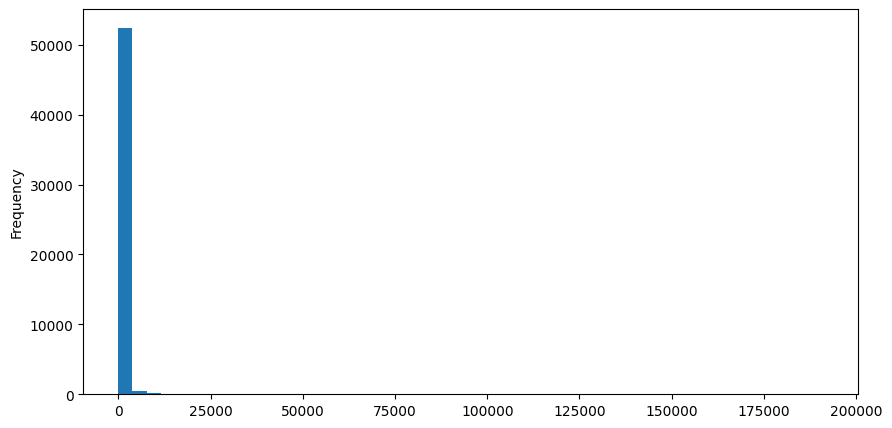

In [21]:
df_counts = df_3.value_counts().reset_index()
df_counts.columns = ['Street Name', 'count']

df_counts['count'].plot.hist(bins=50, figsize=(10, 5))

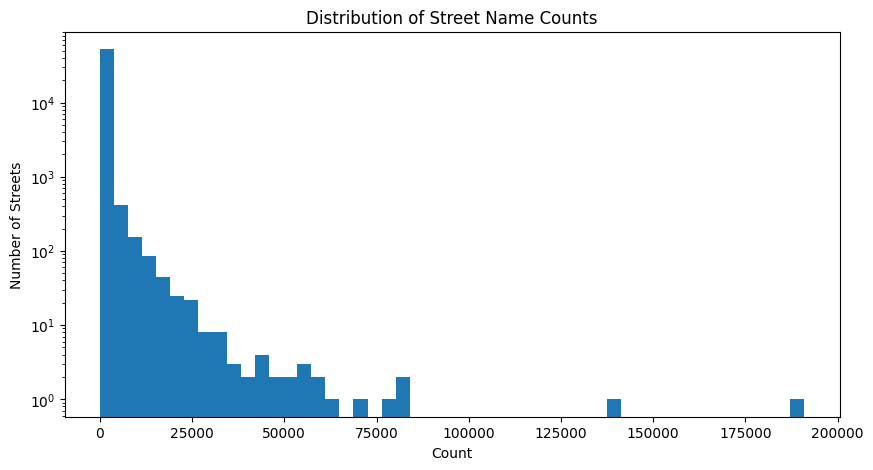

In [22]:
import matplotlib.pyplot as plt

df_counts['count'].plot.hist(bins=50, figsize=(10, 5), logy=True)
plt.xlabel('Count')
plt.ylabel('Number of Streets')
plt.title('Distribution of Street Name Counts')
plt.show()

In [23]:
df_3.isna().sum()

np.int64(0)

In [24]:
import re
import pandas as pd

def normalize_street_name(street_name):
    # it removes the "/" character and everything directly next to it; this regex was crafted with the help of AI.
    pattern = r'\S*\/\S*'
    return re.sub(pattern, '', street_name).strip()

# Példa használat:
df_3= df_3.apply(normalize_street_name)

In [25]:
df_3.value_counts().reset_index()

,Street Name,count
0,BROADWAY,191282
1,3RD AVE,138963
2,5TH AVE,83252
3,MADISON AVE,81896
4,2ND AVE,79886
...,...,...
34971,211-40 47 AVE,1
34972,FAMILIA,1
34973,HATTIE PLACE,1
34974,GLOVERS ROCK,1


In [26]:
df_3.value_counts().reset_index().sample(30)

,Street Name,count
23534,LINCLON PL,1
20131,TIOGA STREET,2
25952,CRAMWELL AVE,1
33917,CLARK PL EAST,1
12004,455 MAIN STREET,9
...,...,...
6968,48 AV,44
11726,UPPER HIGHLAND PARKI,10
22703,NEW DORP PLAZA,1
3830,BRIGHAM ST,211


In [27]:
df_3[df_3.str.contains('AQUEDUCT', case=False, na=False)]

57706          AQUEDUCT AVE
66617         AQUEDUCT WALK
66618         AQUEDUCT WALK
72344          AQUEDUCT AVE
72345       AQUEDUCT AVENUE
                 ...       
12446709       AQUEDUCT AVE
12491281       AQUEDUCT AVE
12491822       AQUEDUCT AVE
12491823       AQUEDUCT AVE
12492472       AQUEDUCT AVE
Name: Street Name, Length: 1327, dtype: str

In [28]:
short_to_long = {
    r'\bAVE\b': 'AVENUE',
    r'\bAV\b': 'AVENUE',
    r'\bBLVD\b': 'BOULEVARD',
    r'\bBVD\b': 'BOULEVARD',
    r'\bCT\b': 'COURT',
    r'\bDR\b': 'DRIVE',
    r'\bLN\b': 'LANE',
    r'\bPKWY\b': 'PARKWAY',
    r'\bPL\b': 'PLACE',
    r'\bRD\b': 'ROAD',
    r'\bST\b': 'STREET',
    r'\bSQ\b': 'SQUARE',
    r'\bTER\b': 'TERRACE',
    r'\bWY\b': 'WAY',
    r'\bHWY\b': 'HIGHWAY',
    r'\bEXPY\b': 'EXPRESSWAY',
    r'\bBR\b': 'BRIDGE',
    r'\bTPKE\b': 'TURNPIKE'
}

def replace_short_forms(text):
    for short, long in short_to_long.items():
        text = re.sub(short, long, text)
    return text

df_3= df_3.apply(replace_short_forms)

In [ ]:
df_3.value_counts().reset_index()

# with a little help from regex-based AI,
# i managed to reduce the various street name categories by about 50%

,Street Name,count
0,BROADWAY,191282
1,3RD AVENUE,140984
2,5TH AVENUE,84521
3,MADISON AVENUE,82435
4,2ND AVENUE,80711
...,...,...
28488,211-40 47 AVENUE,1
28489,FAMILIA,1
28490,HATTIE PLACE,1
28491,GLOVERS ROCK,1


#### Beyond the exercise_3
##### Would you need to clean up the Registration State column? Why or why not?

In [ ]:
df['Registration State'].value_counts().index.to_list()

# the '99' is probably an error, and there are Canadian provinces as well, but these can remain as they are.

['NY',
 'NJ',
 'PA',
 'FL',
 'CT',
 'IN',
 'MA',
 'VA',
 'NC',
 'MD',
 'TX',
 'GA',
 'ME',
 'IL',
 'OH',
 'SC',
 'AZ',
 '99',
 'CA',
 'MN',
 'GV',
 'TN',
 'OK',
 'DE',
 'MI',
 'OR',
 'WI',
 'RI',
 'AL',
 'WA',
 'NH',
 'VT',
 'ON',
 'MO',
 'LA',
 'CO',
 'KY',
 'QB',
 'DC',
 'WV',
 'DP',
 'MS',
 'IA',
 'SD',
 'AR',
 'NV',
 'KS',
 'UT',
 'ID',
 'NE',
 'NM',
 'MT',
 'AK',
 'ND',
 'WY',
 'PR',
 'HI',
 'AB',
 'NS',
 'BC',
 'NB',
 'FO',
 'MB',
 'PE',
 'SK',
 'MX',
 'NT',
 'YT']